# MNIST From Scratch

**Companion notebook to Class 3 — Machine Learning Foundations.**

In class we covered the recipe: *parameters → predictions → loss → gradient descent → repeat.*
Here we run it, on real data, with nothing but NumPy.

Every part of the model is written out below — the parameters, the softmax, the loss, and
the gradient step. If you can read this notebook, you can explain how a classifier works.

Run the cells top to bottom.

---
## 1. Get the data

MNIST is 70,000 handwritten digits, collected from US Census Bureau employees and high
school students. It is the most-used dataset in the history of machine learning.

The cell below downloads it once (11 MB) and caches it in `data/`. Every run after the
first starts instantly.

In [35]:
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
PATH = Path("data/mnist.npz")

if not PATH.exists():
    PATH.parent.mkdir(exist_ok=True)
    print("Downloading MNIST (11 MB) — this happens once...")
    urllib.request.urlretrieve(URL, PATH)

with np.load(PATH) as d:
    train_images, train_labels = d["x_train"], d["y_train"]
    test_images, test_labels = d["x_test"], d["y_test"]

print(f"Training set: {train_images.shape[0]:,} images")
print(f"Test set:     {test_images.shape[0]:,} images  (the model never trains on these)")
print(f"Each image:   {train_images.shape[1]} x {train_images.shape[2]} pixels, values 0-255")

Training set: 60,000 images
Test set:     10,000 images  (the model never trains on these)
Each image:   28 x 28 pixels, values 0-255


Note that MNIST arrives **already split** into a training set and a test set. We did not
choose that split, and we are not allowed to peek at the test half until the very end.
That is the whole discipline of honest evaluation, handed to us for free.

---
## 2. Look at what we are training on

Never train on data you have not looked at. Run this cell a few times — it picks a
**different random sample every run**.

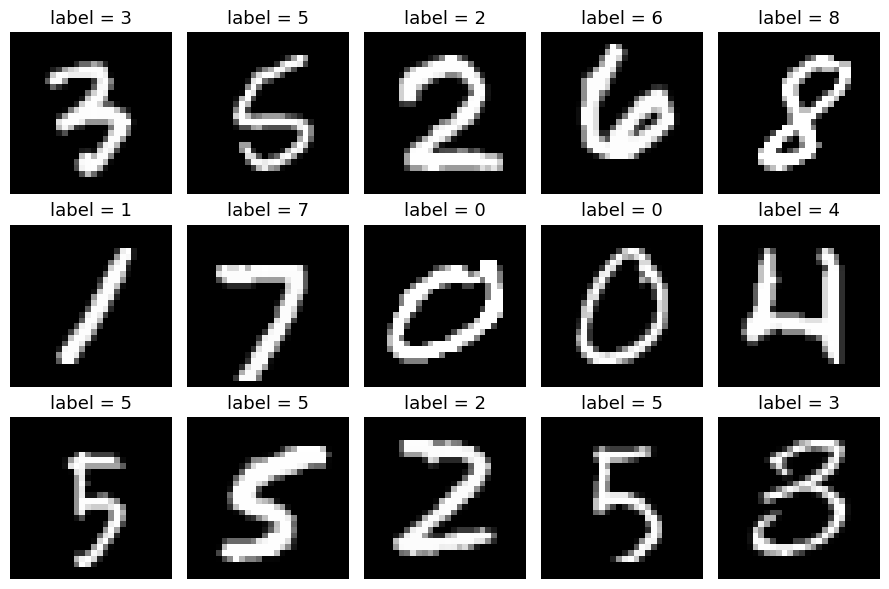

In [36]:
def show_digits(images, titles, rows=3, cols=5, figsize=(9, 6)):
    """Render a grid of MNIST digits, white ink on black, the way the raw data looks."""
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    for ax, image, title in zip(axes.ravel(), images, titles):
        ax.imshow(image, cmap="gray")
        ax.set_title(title, fontsize=13)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


sample = np.random.choice(len(train_images), 15, replace=False)
show_digits(train_images[sample], [f"label = {train_labels[i]}" for i in sample])

Some of these are neat. Some are genuinely ambiguous — you will find 4s that could be 9s
and 5s that could be 3s. **That is real handwriting**, and it is the ceiling on how well
any model can possibly do.

Run the cell again for a fresh batch.

---
## 3. A digit is just numbers in a grid

To a computer an image is not a picture. It is a grid of brightness values: `0` is black,
`255` is full white. Here is one digit shown both ways.

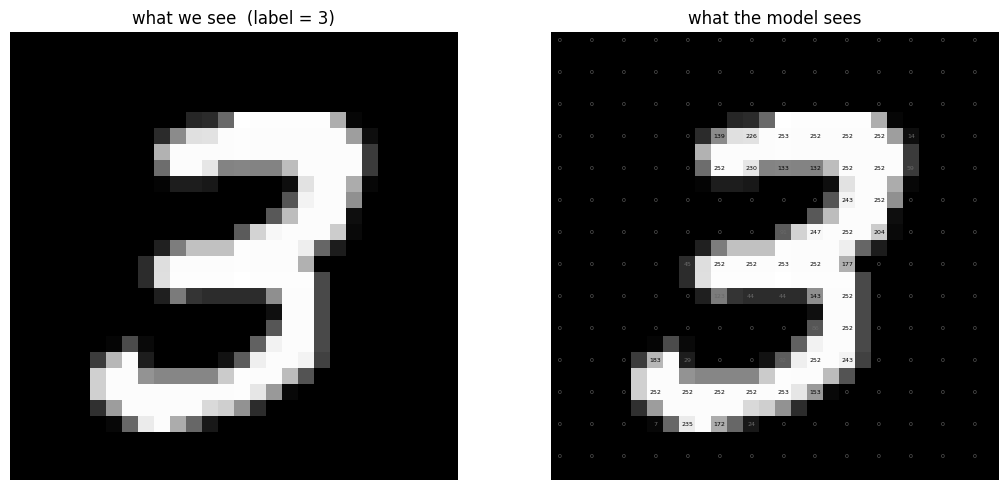

One image is a (28, 28) grid = 784 numbers.
Flatten it into a single row and you have 784 features —
exactly like 'ad spend' and 'visits per month' from class, just more of them.


In [37]:
i = int(np.flatnonzero(train_labels == 3)[0])
image = train_images[i]

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 5))
left.imshow(image, cmap="gray")
left.set_title(f"what we see  (label = {train_labels[i]})")
left.axis("off")

right.imshow(image, cmap="gray")
right.set_title("what the model sees")
right.axis("off")
for row in range(0, 28, 2):          # every other pixel, or it is unreadable
    for col in range(0, 28, 2):
        value = image[row, col]
        right.text(col, row, str(value), fontsize=4.5, ha="center", va="center",
                   color="black" if value > 128 else "dimgray")
plt.tight_layout()
plt.show()

print(f"One image is a {image.shape} grid = {image.size} numbers.")
print("Flatten it into a single row and you have 784 features —")
print("exactly like 'ad spend' and 'visits per month' from class, just more of them.")

---
## 4. Prepare the data

Two small steps:

- **Flatten** each 28×28 grid into a row of 784 numbers, because our model takes a flat
  list of features
- **Scale** from 0–255 down to 0–1, which keeps the arithmetic well behaved during training

And one bookkeeping step: turn each label into a row of 10 columns (a `7` becomes
`0 0 0 0 0 0 0 1 0 0`) so we can compare it against 10 predicted probabilities.

In [26]:
X_train = train_images.reshape(len(train_images), -1) / 255.0
X_test = test_images.reshape(len(test_images), -1) / 255.0
y_train, y_test = train_labels, test_labels

Y_train_onehot = np.eye(10)[y_train]

print(f"X_train: {X_train.shape}   (60,000 images, 784 pixels each)")
print(f"X_test:  {X_test.shape}")
print(f"pixel range now: {X_train.min():.0f} to {X_train.max():.0f}")
print(f"\nlabel {y_train[0]} becomes {Y_train_onehot[0].astype(int)}")

X_train: (60000, 784)   (60,000 images, 784 pixels each)
X_test:  (10000, 784)
pixel range now: 0 to 1

label 5 becomes [0 0 0 0 0 1 0 0 0 0]


---
## 5. The model

The model is the same shape as the straight line from class, just wider.

For **each** of the 10 digits, keep **one weight per pixel** — how much that pixel counts as
evidence for that digit. That is 784 × 10 = 7,840 weights, plus 10 biases:

**7,850 parameters.** Those are all the knobs there are.

To classify an image: multiply every pixel by its weight, add them up, and you get 10
scores — one per digit. `softmax` turns those scores into probabilities that sum to 1, and
the highest one is the answer.

In [27]:
def softmax(scores):
    scores = scores - scores.max(axis=1, keepdims=True)   # keeps the exponentials stable
    exp = np.exp(scores)
    return exp / exp.sum(axis=1, keepdims=True)


W = np.zeros((784, 10))   # 7,840 weights, all starting at zero
b = np.zeros(10)          # 10 biases

print(f"Total parameters: {W.size + b.size:,}")
print("\nUntrained guesses for the first image:")
print(np.round(softmax(X_train[:1] @ W + b)[0], 3))

Total parameters: 7,850

Untrained guesses for the first image:
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


Ten equal probabilities of 0.1. The model knows nothing at all — it is guessing uniformly
across the ten digits.

**Now we turn the knobs.**

---
## 6. Train

This is gradient descent, written out. It is the exact five-step loop from class:

1. **Predict** with the current parameters
2. **Measure the loss** — how wrong those predictions were
3. Work out **which way is downhill** for every parameter
4. Take a **small step** that way
5. **Repeat**

Watch the loss fall. That is the entire show.

In [28]:
learning_rate = 0.5
epochs = 300

history = []
for epoch in range(epochs + 1):
    probs = softmax(X_train @ W + b)                                          # 1. predict
    loss = -np.mean(np.log(probs[np.arange(len(y_train)), y_train] + 1e-9))   # 2. loss
    grad = (probs - Y_train_onehot) / len(y_train)                            # 3. downhill
    W -= learning_rate * (X_train.T @ grad)                                   # 4. step
    b -= learning_rate * grad.sum(axis=0)                                     # 4. step
                                                                              # 5. repeat
    accuracy = (probs.argmax(axis=1) == y_train).mean()
    history.append((loss, accuracy))
    if epoch % 25 == 0:
        bar = "#" * int(loss * 20)
        print(f"epoch {epoch:>3}   loss {loss:5.3f}   train accuracy {accuracy:6.1%}   {bar}")

epoch   0   loss 2.303   train accuracy   9.9%   ##############################################
epoch  25   loss 0.559   train accuracy  86.6%   ###########
epoch  50   loss 0.459   train accuracy  88.2%   #########
epoch  75   loss 0.417   train accuracy  89.0%   ########
epoch 100   loss 0.393   train accuracy  89.5%   #######
epoch 125   loss 0.376   train accuracy  89.8%   #######
epoch 150   loss 0.364   train accuracy  90.1%   #######
epoch 175   loss 0.354   train accuracy  90.3%   #######
epoch 200   loss 0.347   train accuracy  90.4%   ######
epoch 225   loss 0.341   train accuracy  90.6%   ######
epoch 250   loss 0.335   train accuracy  90.7%   ######
epoch 275   loss 0.331   train accuracy  90.9%   ######
epoch 300   loss 0.326   train accuracy  91.0%   ######


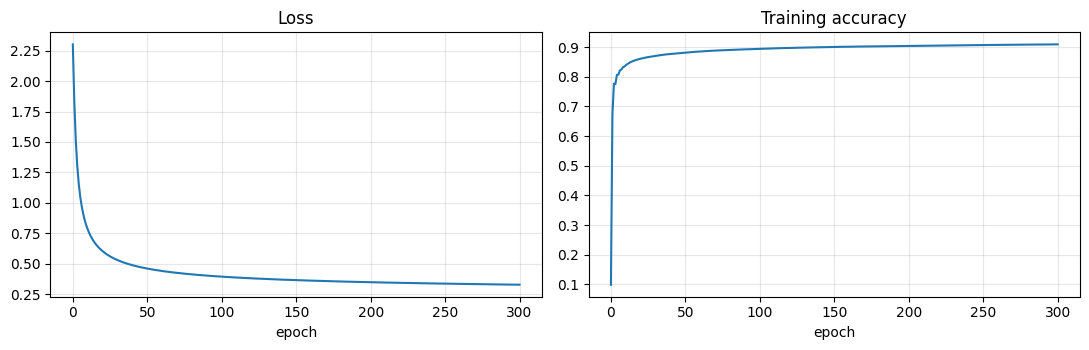

In [29]:
losses = [h[0] for h in history]
accuracies = [h[1] for h in history]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.plot(losses); a1.set_title("Loss"); a1.set_xlabel("epoch"); a1.grid(alpha=0.3)
a2.plot(accuracies); a2.set_title("Training accuracy"); a2.set_xlabel("epoch"); a2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Nobody told the model what a `7` looks like. It found 7,850 numbers that happen to separate
sevens from everything else, by being wrong a few hundred times and adjusting.

---
## 7. The real test: 10,000 digits it has never seen

Training accuracy is not evidence. A model that only performs on data it has already seen
is a lookup table with extra steps.

This is the held-out test set — 10,000 images the model has never touched.

In [30]:
test_probs = softmax(X_test @ W + b)
predictions = test_probs.argmax(axis=1)
test_accuracy = (predictions == y_test).mean()
wrong = np.flatnonzero(predictions != y_test)

print(f"Training accuracy:  {accuracies[-1]:.1%}")
print(f"TEST accuracy:      {test_accuracy:.1%}   <- the number that counts")
print(f"\nGot {len(wrong):,} of {len(y_test):,} wrong.")

Training accuracy:  91.0%
TEST accuracy:      91.5%   <- the number that counts

Got 854 of 10,000 wrong.


The two numbers are close, which is the good case: the model learned a pattern that
**generalizes** rather than memorizing its training data.

---
## 8. Look at what it got wrong

The most useful thing you can do with a model is study its mistakes.

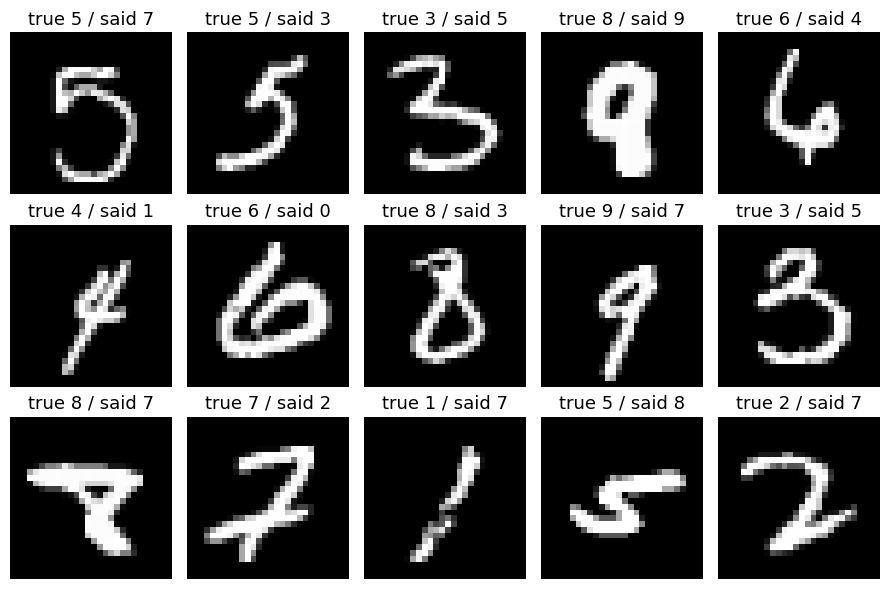

In [31]:
picks = np.random.choice(wrong, 15, replace=False)
show_digits(
    test_images[picks],
    [f"true {y_test[i]} / said {predictions[i]}" for i in picks],
)

Look closely before blaming the model. A lot of these are digits **you** would hesitate on —
4s written like 9s, 5s written like 3s, a 1 with a heavy serif that reads as a 2.

This is what a real error rate looks like: not incompetence, but genuine ambiguity plus a
model that is simpler than the problem.

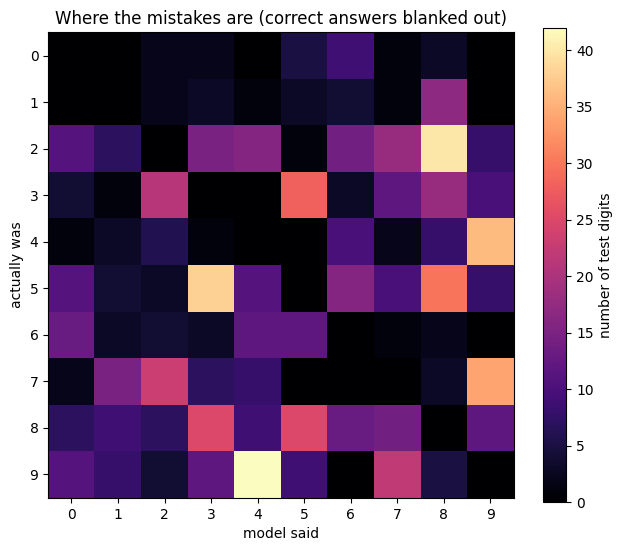

Most common confusions:
  a real 9 called a 4:  42 times
  a real 2 called a 8:  40 times
  a real 5 called a 3:  38 times
  a real 4 called a 9:  36 times
  a real 7 called a 9:  34 times


In [32]:
# Which digits does it confuse most often?
confusion = np.zeros((10, 10), dtype=int)
for true, pred in zip(y_test, predictions):
    confusion[true, pred] += 1

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(np.where(np.eye(10, dtype=bool), 0, confusion), cmap="magma")
ax.set_xlabel("model said"); ax.set_ylabel("actually was")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_title("Where the mistakes are (correct answers blanked out)")
plt.colorbar(im, ax=ax, label="number of test digits")
plt.tight_layout()
plt.show()

worst = np.dstack(np.unravel_index(
    np.argsort(np.where(np.eye(10, dtype=bool), 0, confusion), axis=None)[::-1], (10, 10)))[0][:5]
print("Most common confusions:")
for true, pred in worst:
    print(f"  a real {true} called a {pred}:  {confusion[true, pred]} times")

---
## 9. Push it until it breaks

91% sounds like the model understands handwriting. It does not.

Here is the test. We take the same test digits and **slide them a few pixels sideways** —
something no human would even notice. Nothing about the handwriting changes.

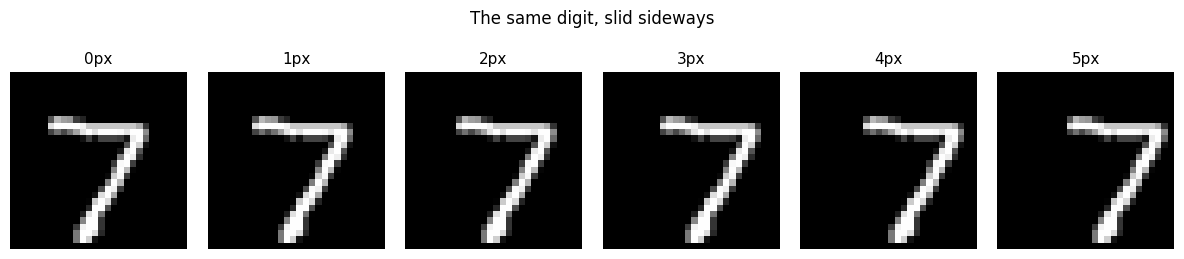

In [33]:
digit = test_images[0]
fig, axes = plt.subplots(1, 6, figsize=(12, 2.4))
for ax, shift in zip(axes, range(6)):
    ax.imshow(np.roll(digit, shift, axis=1), cmap="gray")
    ax.set_title(f"{shift}px", fontsize=11)
    ax.axis("off")
plt.suptitle("The same digit, slid sideways", y=1.06)
plt.tight_layout()
plt.show()

shift   accuracy
  0px    91.5%   #############################################
  1px    85.6%   ##########################################
  2px    65.7%   ################################
  3px    43.3%   #####################
  4px    23.2%   ###########
  5px    11.5%   #####


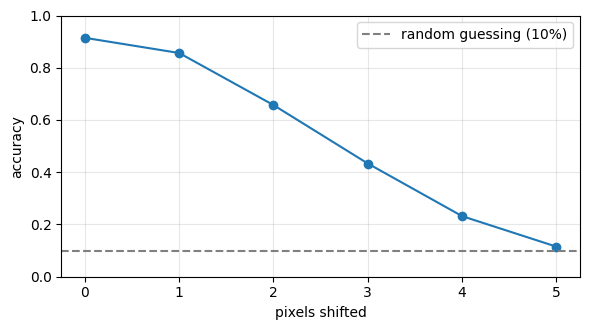

In [34]:
print("shift   accuracy")
shifts, scores = [], []
for shift in range(6):
    shifted = np.roll(test_images / 255.0, shift, axis=2).reshape(len(test_images), -1)
    score = (softmax(shifted @ W + b).argmax(axis=1) == y_test).mean()
    shifts.append(shift); scores.append(score)
    print(f"  {shift}px   {score:6.1%}   {'#' * int(score * 50)}")

plt.figure(figsize=(6, 3.4))
plt.plot(shifts, scores, marker="o")
plt.axhline(0.1, ls="--", c="gray", label="random guessing (10%)")
plt.xlabel("pixels shifted"); plt.ylabel("accuracy"); plt.ylim(0, 1)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

From 91% to roughly **random guessing**, from a shift you can barely see.

Here is why. Our model has one weight per *pixel position*. It never learned what a `3`
**looks like** — it learned **which pixels tend to be lit** when someone writes a 3, in the
exact centre of a 28×28 box, the way MNIST happens to be formatted. Move the ink and every
weight is pointing at the wrong place.

This is the single most common failure mode in deployed ML: the world shifts slightly out
of the distribution the model was trained on, and performance falls off a cliff while the
training metrics still look great.

---
## 10. What you just did

- You trained a **real classifier on real data** — 7,850 parameters, cross-entropy loss,
  gradient descent — in about twenty lines of NumPy
- You got **~91% on ten thousand digits it had never seen**, and you checked that number
  honestly instead of trusting the training score
- You looked at its mistakes and found most of them were genuinely hard
- You broke it on purpose, and you can explain exactly why it broke

The "AI reads handwriting" magic is: pixels in, weighted sums out, loss pushed downhill a
few hundred times. That is it. The same loop — scaled to billions of parameters, and to
text instead of pixels — is how the language models in Class 5 were trained.

### Where this goes next

The shift experiment is the argument for the next class. A **convolutional neural network**
learns small visual patterns — an edge, a curve, a loop — and looks for them *anywhere* in
the image rather than at fixed pixel positions. That one change takes this task from ~91%
to ~99%, and survives the shift that just destroyed us.

That is **Class 4**.

### Try it yourself

- Turn `learning_rate` up to `5.0` or down to `0.01`. What happens to the loss curve?
- Train for 50 epochs instead of 300. How much accuracy do you actually lose?
- Train on only the first 1,000 images. Does the gap between training and test accuracy grow?
- `plt.imshow(W[:, 3].reshape(28, 28), cmap="RdBu")` draws the weights for digit 3.
  Can you see a 3 in it?